<h1 style="color:blue">Prvi domaci iz AS -
Aleksa Boskovic</h1>

In [55]:
# potrebne biblioteke i ucitavanje date datoteke magnetnog polja
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import math
import seaborn as sns
from scipy.stats import norm, expon, uniform, laplace
from scipy.optimize import curve_fit
from scipy.stats import skew, kurtosis
matplotlib.rcParams.update({"text.usetex": False, "font.size" : 10, "font.family": "monospace"})


data = np.load('/home/arekysa/Documents/Fakultet/III_Godina/AS/domaci/1_domaci/sunspot.npz')
B2d = data['B']
theta2d = np.degrees(data['inc'])
phi2d = np.degrees(data['az'])

# cisto za proveru da li je sve lepo ucitano
print(B2d.shape)
print(theta2d.shape)
print(phi2d.shape)


(64, 512)
(64, 512)
(64, 512)


1. Potrebno je prikazati mape i histograme za B, $\theta$, $\varphi$ pojedinacno.

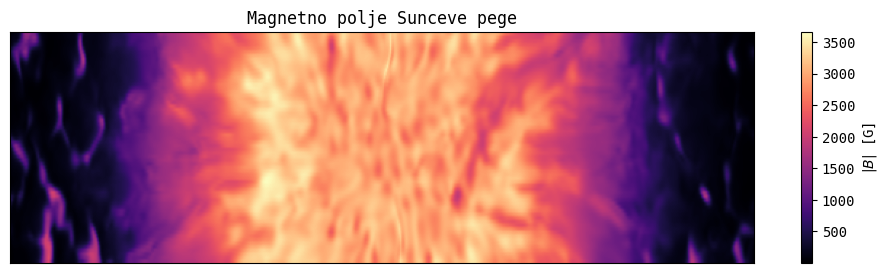

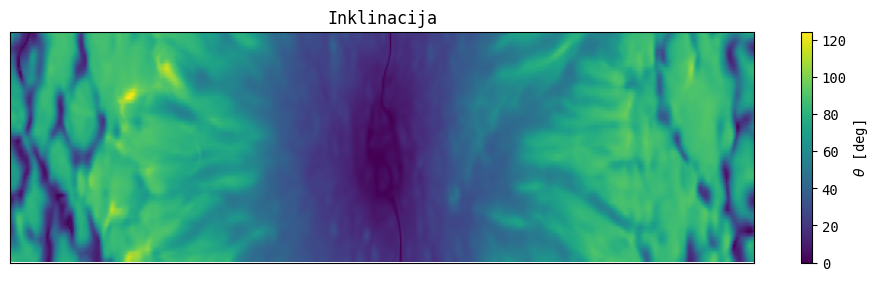

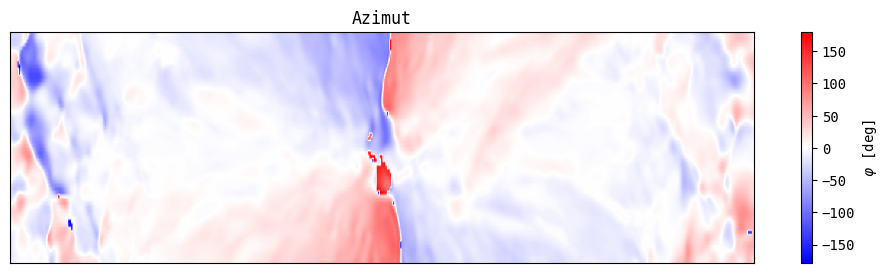

In [44]:
#2d mape za svaki pojedinacno

plt.figure(figsize = (12,3))
B_mapa = plt.imshow(B2d, origin='lower',cmap = 'magma', aspect='auto')
plt.title(r'Magnetno polje Sunceve pege')
plt.colorbar(B_mapa, label=r'$|B|$ [G]')
plt.xticks([])
plt.yticks([])
plt.show()


plt.figure(figsize = (12,3))
theta_mapa = plt.imshow(theta2d, origin='lower',cmap = 'viridis', aspect='auto')
plt.title(r'Inklinacija')
plt.colorbar(theta_mapa, label=r'$\theta$ [deg]')
plt.xticks([])
plt.yticks([])
plt.show()

plt.figure(figsize = (12,3))
phi_mapa = plt.imshow(phi2d, origin='lower',cmap = 'bwr', aspect='auto')
plt.title(r'Azimut')
plt.colorbar(phi_mapa, label=r'$\varphi$ [deg]')
plt.xticks([])
plt.yticks([])
plt.show()

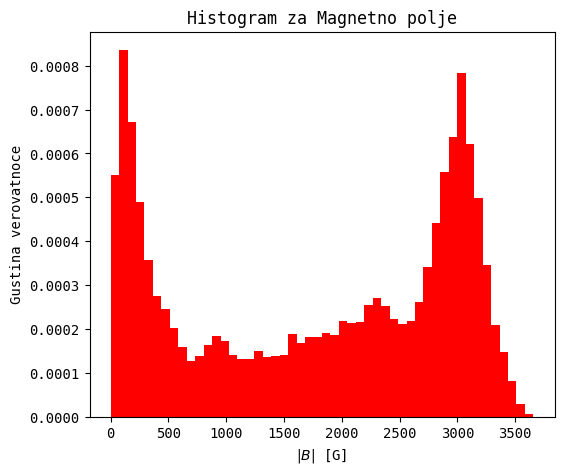

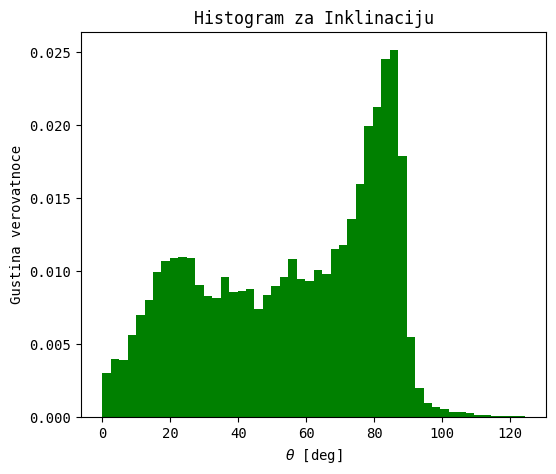

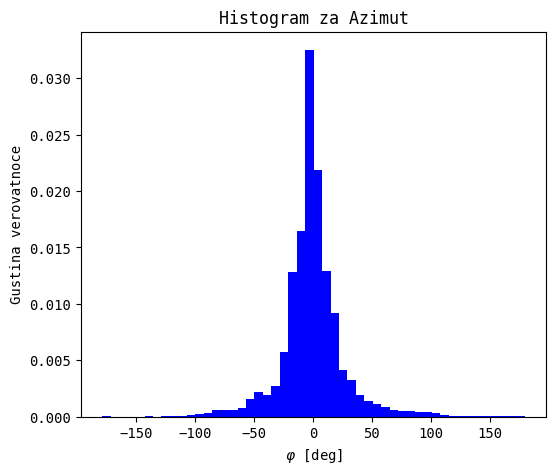

In [45]:
# histogrami za svaki posebno
B = B2d.flatten()
theta = theta2d.flatten()
phi = phi2d.flatten()


plt.figure(figsize=(6, 5))
hist_B, bins_B, _ = plt.hist(B, bins=50, density=True, color='red')
plt.xlabel(r'$|B|$ [G]')      
plt.ylabel('Gustina verovatnoce') 
plt.title('Histogram za Magnetno polje')
plt.show()


plt.figure(figsize=(6, 5))
hist_th, bins_th, _ = plt.hist(theta, bins=50, density=True, color='green')
plt.xlabel(r'$\theta$ [deg]')
plt.ylabel('Gustina verovatnoce')
plt.title('Histogram za Inklinaciju')
plt.show() 


plt.figure(figsize=(6, 5))
hist_ph, bins_ph, _ = plt.hist(phi, bins=50, density=True, color='blue')
plt.xlabel(r'$\varphi$ [deg]')
plt.ylabel('Gustina verovatnoce')
plt.title('Histogram za Azimut')
plt.show()


2. Magnetno polje modelovati funkcijom raspodele verovatnoce koja je kombinacija normalne, eksponencijalne i uniformne raspodele. Inklinaciju modelovati raspodelom koja je kombinacija normalne i eksponencijalne raspodele. Sto se tice azimuta, iskoristiti Laplasovu funkciju raspodele. Plotovati krive dobijenih funkcija preko histograma pojedinacno 

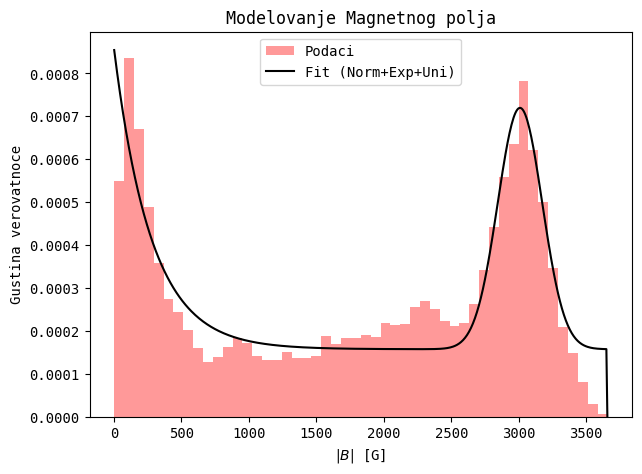

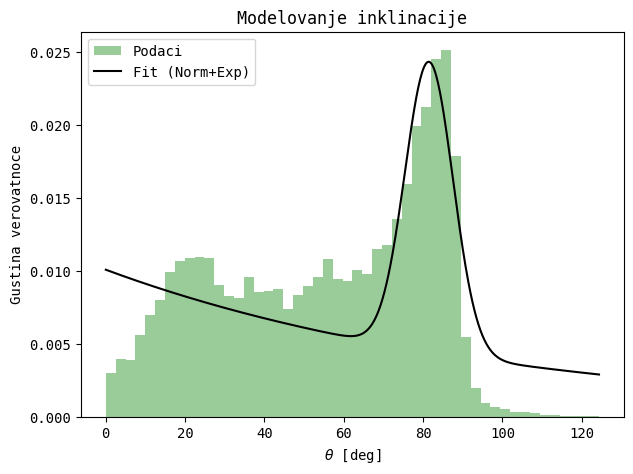

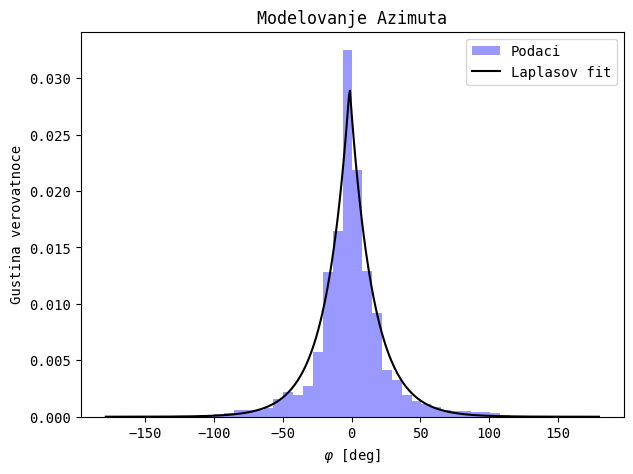

In [54]:
x_B = (bins_B[:-1] + bins_B[1:]) / 2
x_th = (bins_th[:-1] + bins_th[1:]) / 2
B_min = np.min(B) # uvedeno da bi se fiksirao pocetak na najmanju izmerenu vrednost kod eksponencijalne i unifrmne raspodele
B_max = np.max(B) 

def model_B(x, w1, mu, sigma, w2, exp_scale, w3):
    norm_deo = w1 * norm.pdf(x, loc=mu, scale=sigma)
    exp_deo  = w2 * expon.pdf(x, loc=B_min, scale=exp_scale)
    uni_deo  = w3 * uniform.pdf(x, loc=B_min, scale=B_max - B_min)
    return norm_deo + exp_deo + uni_deo


th_min = np.min(theta)

def model_theta(x, w1, mu, sigma, w2, exp_scale):
    norm_deo = w1 * norm.pdf(x, loc=mu, scale=sigma)
    exp_deo  = w2 * expon.pdf(x, loc=th_min, scale=exp_scale)
    return norm_deo + exp_deo


plt.figure(figsize=(7, 5))
# isti histogram iz 1 samo smanjen intenzitet boje da se bolje vidi fit
plt.hist(B, bins=50, density=True, color='red', alpha=0.4, label='Podaci')

# p0 = [w1, mu, sigma, w2, exp_scale, w3]
p0_B = [0.5, np.mean(B), np.std(B), 0.3, np.std(B), 0.2]
popt_B, pcov_B = curve_fit(model_B, x_B, hist_B, p0=p0_B)
x_plot_B = np.linspace(B_min, B_max, 500)
plt.plot(x_plot_B, model_B(x_plot_B, *popt_B), color='black',label='Fit (Norm+Exp+Uni)')
plt.xlabel(r'$|B|$ [G]')
plt.ylabel('Gustina verovatnoce')
plt.title('Modelovanje Magnetnog polja')
plt.legend()
plt.show()


plt.figure(figsize=(7, 5))
plt.hist(theta, bins=50, density=True, color='green', alpha=0.4, label='Podaci')

p0_th = [0.5, np.mean(theta), np.std(theta), 0.5, np.std(theta)]
popt_th, pcov_th = curve_fit(model_theta, x_th, hist_th, p0=p0_th)
x_plot_th = np.linspace(th_min, np.max(theta), 500)
plt.plot(x_plot_th, model_theta(x_plot_th, *popt_th), color='black', label='Fit (Norm+Exp)')
plt.xlabel(r'$\theta$ [deg]')
plt.ylabel('Gustina verovatnoce')
plt.title('Modelovanje inklinacije')
plt.legend()
plt.show()


plt.figure(figsize=(7, 5))
plt.hist(phi, bins=50, density=True, color='blue', alpha=0.4, label='Podaci')

loc_lap, scale_lap = laplace.fit(phi)
x_plot_ph = np.linspace(np.min(phi), np.max(phi), 500)
plt.plot(x_plot_ph, laplace.pdf(x_plot_ph, loc=loc_lap, scale=scale_lap), color='black', label='Laplasov fit')

plt.xlabel(r'$\varphi$ [deg]')
plt.ylabel('Gustina verovatnoce')
plt.title('Modelovanje Azimuta')
plt.legend()
plt.show()

3. Za svaki od parametara naci $\bar{x}$, $s$, medijanu, $\sigma_G$ ($\bar{x}$ i medijana su linije preko histograma), asimetricnost i kurtosis. Komentarisati robusnost deskriptivnih statistika. Parametar $\sigma_G$ izracunati preko $\sigma_G$ = $q_{75} - q_{25}$.

Deskriptivna statistika za Magnetno polje
Srednja vrednost: 1795.597
Standardna devijacija: 1163.675
Medijana: 2043.229
Sigma_G: 2407.120
Asimetricnost (skew): -0.241
Spljostenost (kurtosis): -1.502

Deskriptivna statistika za Inklinacija
Srednja vrednost: 55.362
Standardna devijacija: 26.306
Medijana: 59.852
Sigma_G: 47.699
Asimetricnost (skew): -0.337
Spljostenost (kurtosis): -1.176

Deskriptivna statistika za Azimut
Srednja vrednost: -0.569
Standardna devijacija: 26.818
Medijana: -1.429
Sigma_G: 21.105
Asimetricnost (skew): 0.443
Spljostenost (kurtosis): 5.735



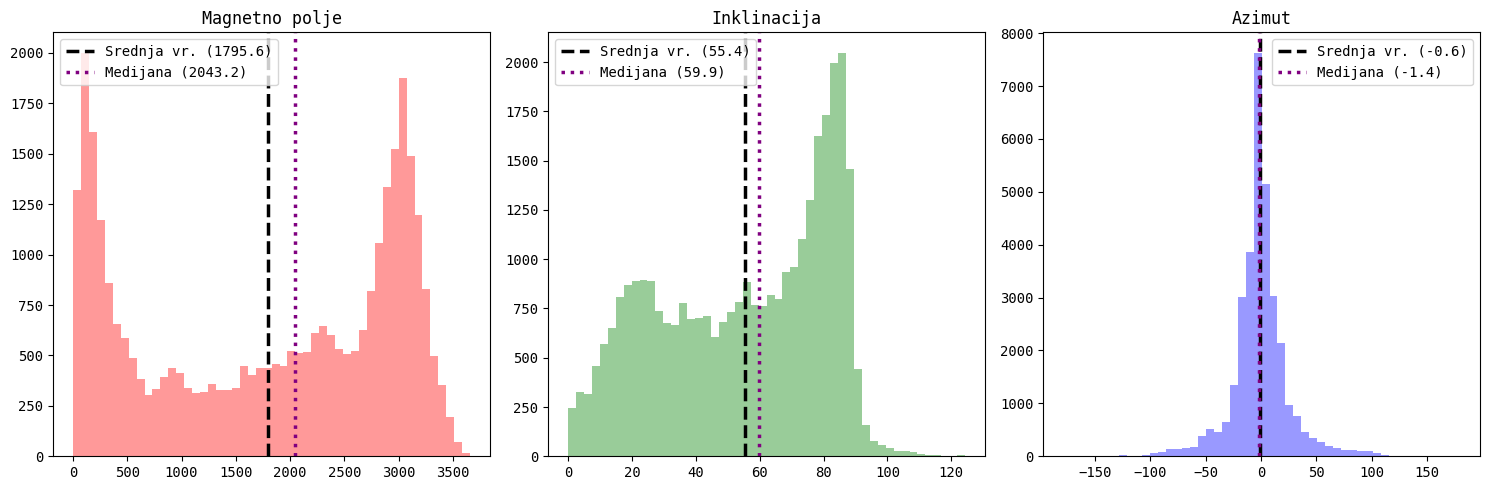

In [63]:
def izracunaj_statistiku(podaci, ime_parametra):
    
    x_sr = np.mean(podaci)
    s = np.std(podaci)
    medijana = np.median(podaci)
    q75, q25 = np.percentile(podaci, [75, 25])
    sigma_G = q75 - q25
    asimetricnost = skew(podaci)
    kurt = kurtosis(podaci)
    
    print(f"Deskriptivna statistika za {ime_parametra}")
    print(f"Srednja vrednost: {x_sr:.3f}")
    print(f"Standardna devijacija: {s:.3f}")
    print(f"Medijana: {medijana:.3f}")
    print(f"Sigma_G: {sigma_G:.3f}")
    print(f"Asimetricnost (skew): {asimetricnost:.3f}")
    print(f"Spljostenost (kurtosis): {kurt:.3f}\n")
    
    return x_sr, medijana


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
nizovi = [B, theta, phi]
imena = ['Magnetno polje', 'Inklinacija', 'Azimut']
boje = ['red', 'green', 'blue']
for i in range(3):
    x_sr, medijana = izracunaj_statistiku(nizovi[i], imena[i])
    axes[i].hist(nizovi[i], bins=50, color=boje[i], alpha=0.4)
    axes[i].axvline(x_sr, color='black', linestyle='dashed', linewidth=2.5, label=f'Srednja vr. ({x_sr:.1f})')
    axes[i].axvline(medijana, color='purple', linestyle='dotted', linewidth=2.5, label=f'Medijana ({medijana:.1f})')
    axes[i].set_title(imena[i])
    axes[i].legend()

plt.tight_layout()
plt.show()

Kod magnetnog polja i inklinacije vidimo da su srednje vrednosti znacajno manje od njihovih medijana sto je direktna posledica negativne asimetricnosti samim tim srednja vrednost nije dovoljno robusna mera jer  na nju veci uticaj imaju nize vrednosti. S druge strane medijana je robusna jer na nju ne uticu ekstremi. Sto se tice azimuta on ima blagu pozitivnu asimetriju ali ono sto je najupadljivije je visok kurtosis.

4. Odraditi proveru centralne granicne teoreme za sva tri parametra. KOmentarisati.